# Phase 3 - Driver CSV Replay

> Project Chrono / Vehicle / Driver  
> 예제 목적: CSV 파일에 저장된 driver input profile을 읽어서 HMMWV에 replay한다.

---

## 0. 이 예제에서 배우는 것

이 노트북은 `time, steering, throttle, braking`이 저장된 CSV 파일을 사용해 차량 입력을 재현한다.

공식 `ChDataDriver`와 개념은 같지만, PyChrono 버전 차이에 덜 민감하도록 여기서는 `numpy.interp()`를 사용해 직접 보간한다.

```text
driver_profile.csv
    ↓
np.interp(time, profile)
    ↓
DriverInputs
    ↓
HMMWV simulation
    ↓
CSV + graph
```

---

## 1. 왜 CSV Replay가 필요한가?

Interactive driver는 사람이 조작하므로 매번 입력이 달라진다.  
반면 CSV replay는 같은 입력을 반복 재현할 수 있다.

따라서 다음 경우에 유용하다.

```text
1. 같은 입력으로 tire model 비교
2. 같은 입력으로 terrain 조건 비교
3. 같은 입력으로 driveline 조건 비교
4. 외부 제어기나 RL policy 결과 replay
```


## 2. Import

In [2]:
import math as m
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pychrono as chrono
import pychrono.vehicle as veh

print("Chrono import success")
print("NumPy version:", np.__version__)


Chrono import success
NumPy version: 1.26.4


## 3. 경로 설정

입력 profile과 결과 파일을 저장할 폴더를 만든다.


In [3]:
def find_project_root(start=None):
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()

    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "docs").exists():
            return p

    return start


PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "phase3" / "driver_csv_replay"
FIGURE_DIR = RESULT_DIR / "figures"
INPUT_DIR = RESULT_DIR / "input_profiles"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
INPUT_DIR.mkdir(parents=True, exist_ok=True)

print("RESULT_DIR:", RESULT_DIR)
print("INPUT_DIR:", INPUT_DIR)


RESULT_DIR: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay
INPUT_DIR: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\input_profiles


## 4. 예제 Driver Input CSV 생성

이번 예제에서는 먼저 간단한 driver input profile CSV를 만든다.

입력 형식:

```text
time, steering, throttle, braking
```

아래 profile은 다음 행동을 의미한다.

```text
0~1 s   : 정지 상태에서 throttle 증가
1~3 s   : 직진 주행
3~5 s   : 오른쪽 조향
5~8 s   : 오른쪽 조향 유지
8~10 s  : 왼쪽 조향으로 전환
10~12 s : throttle 제거 + braking
```


In [4]:
profile = pd.DataFrame({
    "time":     [0.0, 1.0, 3.0, 5.0, 8.0, 10.0, 12.0],
    "steering": [0.0, 0.0, 0.25, 0.25, -0.20, 0.0, 0.0],
    "throttle": [0.0, 0.4, 0.4, 0.4,  0.35, 0.0, 0.0],
    "braking":  [0.0, 0.0, 0.0, 0.0,  0.0,  0.5, 0.0],
})

input_csv_path = INPUT_DIR / "driver_profile_example.csv"
profile.to_csv(input_csv_path, index=False, encoding="utf-8-sig")

print("Saved input profile:", input_csv_path)
display(profile)


Saved input profile: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\input_profiles\driver_profile_example.csv


,time,steering,throttle,braking
0,0.0,0.00,0.00,0.0
1,1.0,0.00,0.40,0.0
2,3.0,0.25,0.40,0.0
3,5.0,0.25,0.40,0.0
4,8.0,-0.20,0.35,0.0
5,10.0,0.00,0.00,0.5
6,12.0,0.00,0.00,0.0


## 5. 입력 Profile 시각화

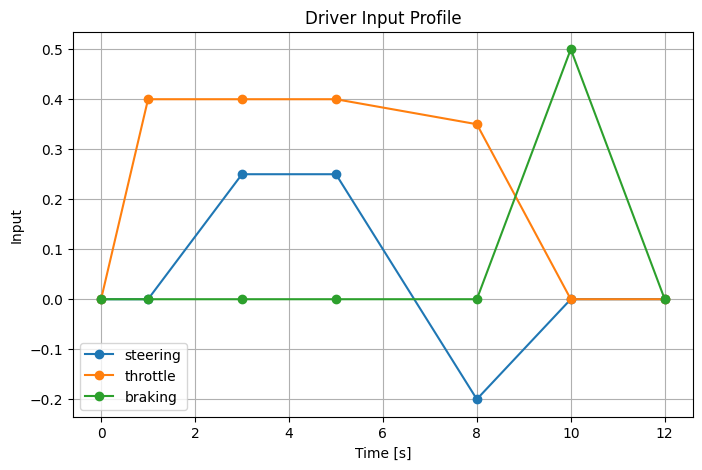

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(profile["time"], profile["steering"], marker="o", label="steering")
plt.plot(profile["time"], profile["throttle"], marker="o", label="throttle")
plt.plot(profile["time"], profile["braking"], marker="o", label="braking")

plt.xlabel("Time [s]")
plt.ylabel("Input")
plt.title("Driver Input Profile")
plt.grid(True)
plt.legend()
plt.show()


## 6. 시뮬레이션 파라미터

CSV profile의 마지막 시간을 시뮬레이션 종료 시간으로 사용한다.


In [6]:
veh.ChWorldFrame.SetYUP()

contact_method = chrono.ChContactMethod_NSC
tire_model = veh.TireModelType_TMEASY

step_size = 3e-3
tire_step_size = 1e-3
t_end = float(profile["time"].max())
terrain_friction = 0.9

print("t_end:", t_end)


t_end: 12.0


## 7. Replay 및 Logging 함수

`replay_inputs()`는 현재 시간 `time`에 대해 CSV profile을 선형 보간하여 driver input을 만든다.

예를 들어:

```text
time = 2.0 s
```

가 CSV에 직접 없더라도, 1초와 3초 사이 값을 보간해서 steering/throttle/braking을 계산한다.


In [7]:
def replay_inputs(time, input_df):
    """CSV profile을 선형 보간하여 현재 시간의 DriverInputs를 생성한다."""
    inputs = veh.DriverInputs()

    inputs.m_steering = float(np.interp(time, input_df["time"], input_df["steering"]))
    inputs.m_throttle = float(np.interp(time, input_df["time"], input_df["throttle"]))
    inputs.m_braking = float(np.interp(time, input_df["time"], input_df["braking"]))

    inputs.m_steering = float(np.clip(inputs.m_steering, -1.0, 1.0))
    inputs.m_throttle = float(np.clip(inputs.m_throttle, 0.0, 1.0))
    inputs.m_braking = float(np.clip(inputs.m_braking, 0.0, 1.0))

    return inputs


def get_chassis_body(hmmwv):
    vehicle = hmmwv.GetVehicle()

    if hasattr(vehicle, "GetChassisBody"):
        return vehicle.GetChassisBody()

    if hasattr(vehicle, "GetChassis"):
        chassis = vehicle.GetChassis()
        if hasattr(chassis, "GetBody"):
            return chassis.GetBody()

    raise RuntimeError("Could not access chassis body.")


def safe_get_rpy_from_body(body):
    try:
        angles = body.GetRot().GetCardanAnglesXYZ()
        return float(angles.x), float(angles.y), float(angles.z)
    except Exception:
        return np.nan, np.nan, np.nan


def get_vehicle_speed(hmmwv, body):
    try:
        return float(hmmwv.GetVehicle().GetSpeed())
    except Exception:
        vel = body.GetPosDt()
        return float((vel.x**2 + vel.y**2 + vel.z**2) ** 0.5)


def log_vehicle_state(hmmwv, driver_inputs, case_name="csv_replay"):
    body = get_chassis_body(hmmwv)
    time = float(hmmwv.GetSystem().GetChTime())

    pos = body.GetPos()
    vel = body.GetPosDt()
    roll, pitch, yaw = safe_get_rpy_from_body(body)
    speed = get_vehicle_speed(hmmwv, body)

    return {
        "case_name": case_name,
        "time": time,

        "x": float(pos.x),
        "y": float(pos.y),
        "z": float(pos.z),

        "vx": float(vel.x),
        "vy": float(vel.y),
        "vz": float(vel.z),

        "speed": speed,
        "roll": roll,
        "pitch": pitch,
        "yaw": yaw,

        "steering": float(driver_inputs.m_steering),
        "throttle": float(driver_inputs.m_throttle),
        "braking": float(driver_inputs.m_braking),
    }


print("Replay helper functions ready")


Replay helper functions ready


## 8. CSV Replay Simulation 실행

아래 셀에서 실제 HMMWV 시뮬레이션을 수행한다.

흐름:

```text
CSV 읽기
→ HMMWV 생성
→ RigidTerrain 생성
→ 매 timestep마다 replay_inputs() 호출
→ Synchronize / Advance
→ 결과 저장
```


In [8]:
input_df = pd.read_csv(input_csv_path)

initLoc = chrono.ChVector3d(0, 1, 10)
initYaw = 0.0

# 1. Vehicle 생성
hmmwv = veh.HMMWV_Reduced()

hmmwv.SetContactMethod(contact_method)
hmmwv.SetChassisCollisionType(veh.CollisionType_NONE)
hmmwv.SetChassisFixed(False)
hmmwv.SetInitPosition(chrono.ChCoordsysd(initLoc, chrono.QuatFromAngleY(initYaw)))

hmmwv.SetEngineType(veh.EngineModelType_SIMPLE)
hmmwv.SetTransmissionType(veh.TransmissionModelType_AUTOMATIC_SIMPLE_MAP)
hmmwv.SetDriveType(veh.DrivelineTypeWV_AWD)
hmmwv.SetTireType(tire_model)
hmmwv.SetTireStepSize(tire_step_size)

hmmwv.Initialize()
hmmwv.GetSystem().SetCollisionSystemType(chrono.ChCollisionSystem.Type_BULLET)

# 2. Terrain 생성
terrain = veh.RigidTerrain(hmmwv.GetSystem())

patch_mat = chrono.ChContactMaterialNSC()
patch_mat.SetFriction(terrain_friction)

terrain.AddPatch(
    patch_mat,
    chrono.ChCoordsysd(chrono.VNULL, chrono.QuatFromAngleX(-m.pi / 2)),
    200.0,
    100.0
)

terrain.Initialize()

# 3. Simulation loop
log_rows = []

while hmmwv.GetSystem().GetChTime() < t_end:
    time = hmmwv.GetSystem().GetChTime()

    # CSV profile에서 현재 시간의 입력 계산
    driver_inputs = replay_inputs(time, input_df)

    log_rows.append(log_vehicle_state(hmmwv, driver_inputs))

    terrain.Synchronize(time)
    hmmwv.Synchronize(time, driver_inputs, terrain)

    terrain.Advance(step_size)
    hmmwv.Advance(step_size)

df = pd.DataFrame(log_rows)

# derived metrics
if len(df) >= 2:
    df["acceleration"] = np.gradient(df["speed"], df["time"])
    df["yaw_rate"] = np.gradient(np.unwrap(df["yaw"].to_numpy()), df["time"])
else:
    df["acceleration"] = np.nan
    df["yaw_rate"] = np.nan

output_csv_path = RESULT_DIR / "driver_csv_replay_log.csv"
df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print("Saved:", output_csv_path)
display(df.head())
display(df.tail())


Saved: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\driver_csv_replay_log.csv


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration,yaw_rate
0,csv_replay,0.000,0.056000,1.213000,10.0,0.000000,0.000000,0.000000e+00,0.000000,-1.570796,0.000000e+00,0.000000,0.0,0.0000,0.0,-1.351101,-0.028312
1,csv_replay,0.003,0.056006,1.212908,10.0,0.001975,-0.030634,-6.863038e-07,-0.004053,-1.570797,-7.627943e-10,-0.000085,0.0,0.0012,0.0,-0.696926,-0.029179
2,csv_replay,0.006,0.056013,1.212716,10.0,0.002207,-0.063879,-2.397985e-06,-0.004182,-1.570797,-1.722348e-09,-0.000175,0.0,0.0024,0.0,-0.012273,-0.030008
3,csv_replay,0.009,0.056019,1.212433,10.0,0.002232,-0.094359,-2.632355e-06,-0.004127,-1.570797,-2.230584e-09,-0.000265,0.0,0.0036,0.0,0.027551,-0.029676
4,csv_replay,0.012,0.056026,1.212061,10.0,0.002198,-0.124062,-2.667831e-06,-0.004016,-1.570797,-2.575917e-09,-0.000353,0.0,0.0048,0.0,0.039815,-0.029021


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,acceleration,yaw_rate
3995,csv_replay,11.985,60.086548,0.630909,-19.643904,0.008342,0.000109,-0.003454,0.009004,-1.578642,0.358673,-0.022409,0.0,0.0,0.00375,-0.060728,-0.000079
3996,csv_replay,11.988,60.086572,0.630910,-19.643915,0.008154,0.000089,-0.003408,0.008812,-1.578642,0.358673,-0.022410,0.0,0.0,0.00300,-0.062548,-0.000070
3997,csv_replay,11.991,60.086596,0.630910,-19.643925,0.007970,0.000069,-0.003364,0.008628,-1.578643,0.358673,-0.022410,0.0,0.0,0.00225,-0.059116,-0.000044
3998,csv_replay,11.994,60.086619,0.630910,-19.643935,0.007796,0.000050,-0.003322,0.008458,-1.578643,0.358673,-0.022410,0.0,0.0,0.00150,-0.057298,-0.000011
3999,csv_replay,11.997,60.086642,0.630910,-19.643944,0.007620,0.000032,-0.003279,0.008284,-1.578643,0.358673,-0.022410,0.0,0.0,0.00075,-0.057689,0.000005


## 9. Speed Response

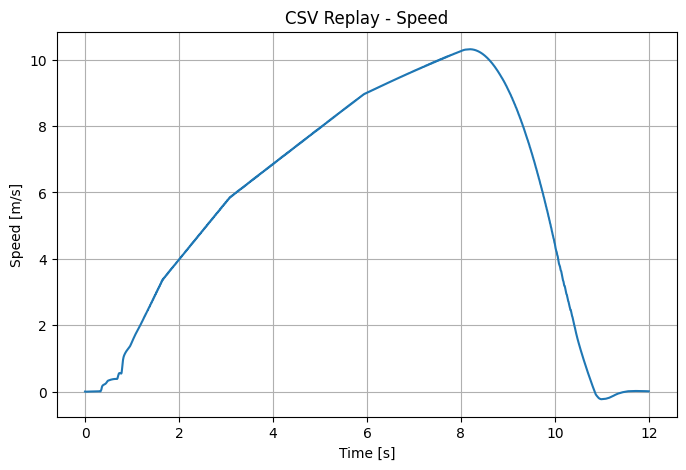

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\figures\csv_replay_speed.png


In [9]:
plt.figure(figsize=(8, 5))

plt.plot(df["time"], df["speed"])

plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("CSV Replay - Speed")
plt.grid(True)

fig_path = FIGURE_DIR / "csv_replay_speed.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 10. Trajectory

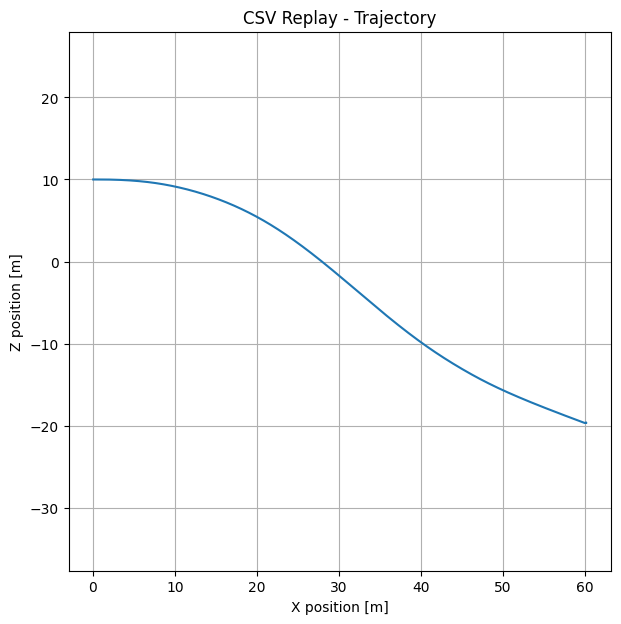

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\figures\csv_replay_trajectory.png


In [10]:
plt.figure(figsize=(7, 7))

plt.plot(df["x"], df["z"])

plt.xlabel("X position [m]")
plt.ylabel("Z position [m]")
plt.title("CSV Replay - Trajectory")
plt.axis("equal")
plt.grid(True)

fig_path = FIGURE_DIR / "csv_replay_trajectory.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 11. 실제 Replay된 Driver Input 확인

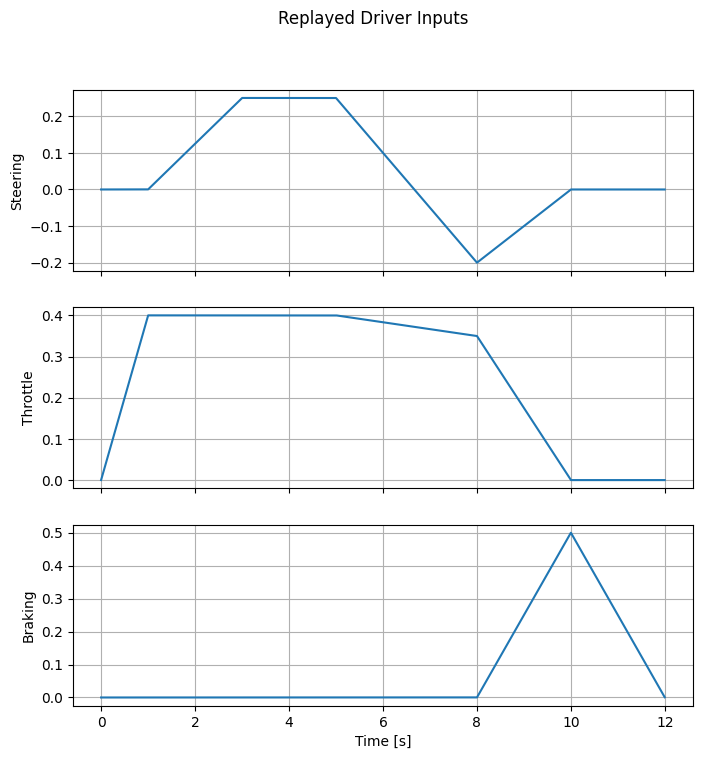

Saved figure: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\figures\csv_replay_inputs.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(df["time"], df["steering"])
axes[1].plot(df["time"], df["throttle"])
axes[2].plot(df["time"], df["braking"])

axes[0].set_ylabel("Steering")
axes[1].set_ylabel("Throttle")
axes[2].set_ylabel("Braking")
axes[2].set_xlabel("Time [s]")

for ax in axes:
    ax.grid(True)

fig.suptitle("Replayed Driver Inputs")

fig_path = FIGURE_DIR / "csv_replay_inputs.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 12. Summary Metrics

In [12]:
summary = pd.DataFrame([{
    "travel_x_m": df["x"].iloc[-1] - df["x"].iloc[0],
    "travel_z_m": df["z"].iloc[-1] - df["z"].iloc[0],
    "mean_speed_mps": df["speed"].mean(),
    "max_speed_mps": df["speed"].max(),
    "max_abs_steering": df["steering"].abs().max(),
    "max_throttle": df["throttle"].max(),
    "max_braking": df["braking"].max(),
}])

summary_path = RESULT_DIR / "driver_csv_replay_summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved summary:", summary_path)
display(summary)


Saved summary: C:\Project_Chrono\Project_Chrono_Practice\results\phase3\driver_csv_replay\driver_csv_replay_summary.csv


,travel_x_m,travel_z_m,mean_speed_mps,max_speed_mps,max_abs_steering,max_throttle,max_braking
0,60.030642,-29.643944,5.6927,10.314559,0.25,0.4,0.49975


## 13. 결과 해석 가이드

해석할 때는 다음 순서로 보면 된다.

```text
1. 입력 profile 그래프 확인
2. replay된 steering/throttle/braking 그래프 확인
3. speed response 확인
4. x-z trajectory 확인
5. summary metric으로 정량 비교
```


```text
CSV replay 방식은 동일한 driver input을 반복적으로 적용할 수 있으므로, 차량 설계 변수나 terrain 조건을 바꿔도 공정한 비교가 가능하다.
따라서 로버 최적설계와 AI 학습용 데이터 생성에서 driver input 재현성 확보에 유용하다.
```
